# 1. IMPORTS


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")

In [2]:
import requests, zipfile
from io import StringIO
import io

#2. LOAD DATA

In [3]:
url = "https://maven-datasets.s3.amazonaws.com/Airline+Flight+Delays/Airlines+Airports+Cancellation+Codes+%26+Flights.zip"
r = requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))

airlines = pd.read_csv(z.open('airlines.csv'))
airports = pd.read_csv(z.open('airports.csv'))
cancellations = pd.read_csv(z.open('cancellation_codes.csv'))
flightss = pd.read_csv(z.open('flights.csv'))
flights = flightss.sample(n=15000, random_state=42).reset_index(drop=True)

In [4]:
""" flights = pd.read_csv("flights.csv")
airlines = pd.read_csv("airlines.csv")
airports = pd.read_csv("airports.csv")
cancellations = pd.read_csv("cancellation_codes.csv") """

' flights = pd.read_csv("flights.csv")\nairlines = pd.read_csv("airlines.csv")\nairports = pd.read_csv("airports.csv")\ncancellations = pd.read_csv("cancellation_codes.csv") '

# 3. MERGE DATA

In [5]:
flights = flights.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
flights.rename(columns={'AIRLINE_y': 'AIRLINE_NAME'}, inplace=True)
flights.drop(columns=['IATA_CODE'], inplace=True)

flights = flights.merge(cancellations, on='CANCELLATION_REASON', how='left')

# **4.Cleaning**

In [6]:
flights.drop_duplicates(inplace=True)

cat_cols_all = flights.select_dtypes(include='object').columns
for col in cat_cols_all:
    flights[col] = flights[col].astype(str).str.strip().str.upper()

# Remove leakage columns
leakage_cols = ['ARRIVAL_TIME','DEPARTURE_TIME','WHEELS_ON','WHEELS_OFF']
flights.drop(columns=leakage_cols, inplace=True)

# Remove useless columns
drop_cols = ['TAIL_NUMBER','FLIGHT_NUMBER','CANCELLATION_REASON']
flights.drop(columns=drop_cols, inplace=True)

# Domain fix
flights.loc[flights['CANCELLED'] == 1, ['ARRIVAL_DELAY','DEPARTURE_DELAY']] = 0

# Outlier capping
for col in ['ARRIVAL_DELAY','DEPARTURE_DELAY']:
    lower = flights[col].quantile(0.01)
    upper = flights[col].quantile(0.99)
    flights[col] = flights[col].clip(lower, upper)


# **5.FEATURE ENGINEERING**

In [7]:
flights['DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype(int)
flights['FLIGHT_TYPE'] = np.where(flights['DISTANCE'] < 1000, 'SHORT', 'LONG')
flights['HOUR'] = flights['SCHEDULED_DEPARTURE'] // 100
flights['IS_WEEKEND'] = (flights['DAY_OF_WEEK'] >= 6).astype(int)

# **6.EDA**

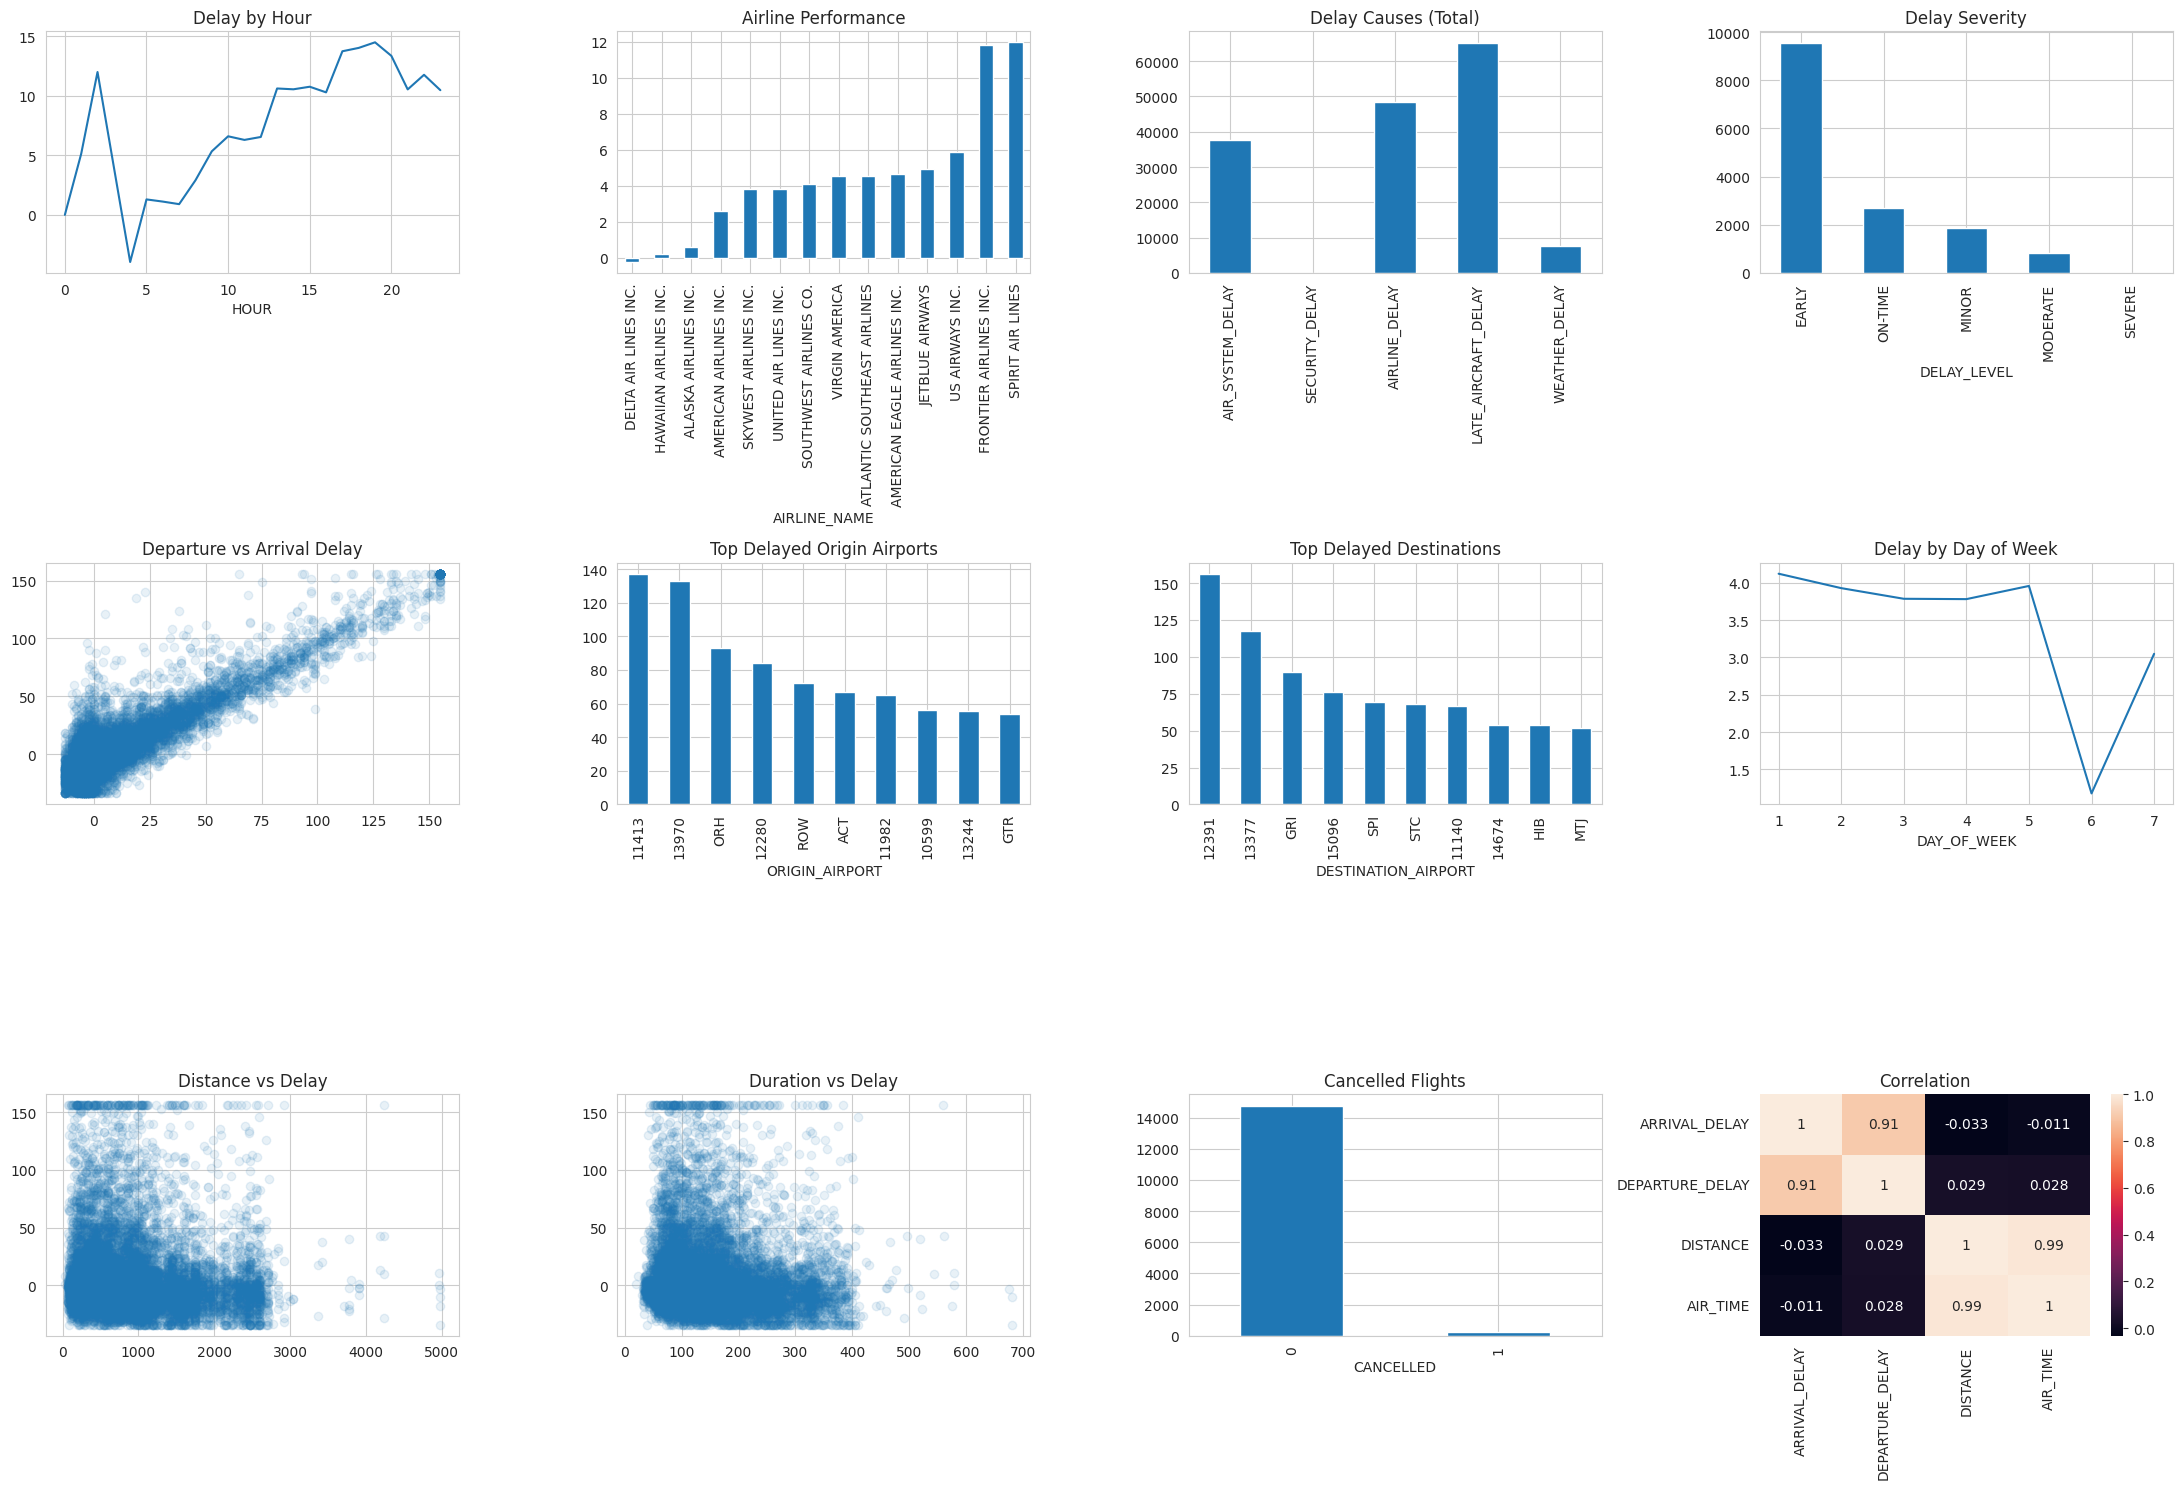

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(22, 15))



# 1 Delay by Hour
flights['HOUR'] = flights['SCHEDULED_DEPARTURE'] // 100
flights.groupby('HOUR')['DEPARTURE_DELAY'].mean().plot(ax=axes[0,0])
axes[0,0].set_title("Delay by Hour")

# 2 Airline Performance
flights.groupby('AIRLINE_NAME')['ARRIVAL_DELAY'].mean().sort_values().plot(
    kind='bar', ax=axes[0,1])
axes[0,1].set_title("Airline Performance")

# 3 Delay Causes (Sum)
delay_cols = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
flights[delay_cols].sum().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title("Delay Causes (Total)")

# 4 Delay Levels
flights['DELAY_LEVEL'] = pd.cut(
    flights['ARRIVAL_DELAY'],
    bins=[-100,0,15,60,300,1000],
    labels=['EARLY','ON-TIME','MINOR','MODERATE','SEVERE']
)
flights['DELAY_LEVEL'].value_counts().plot(kind='bar', ax=axes[0,3])
axes[0,3].set_title("Delay Severity")



# 5 Departure vs Arrival Delay
axes[1,0].scatter(flights['DEPARTURE_DELAY'], flights['ARRIVAL_DELAY'], alpha=0.1)
axes[1,0].set_title("Departure vs Arrival Delay")

# 6 Top Origin Airports
top_airports = flights.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(10)
top_airports.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Top Delayed Origin Airports")

# 7 Top Destination Airports
top_dest = flights.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(10)
top_dest.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title("Top Delayed Destinations")

# 8 Day of Week
flights.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean().plot(ax=axes[1,3])
axes[1,3].set_title("Delay by Day of Week")



# 9 Distance vs Delay
axes[2,0].scatter(flights['DISTANCE'], flights['ARRIVAL_DELAY'], alpha=0.1)
axes[2,0].set_title("Distance vs Delay")

# 10 Flight Duration vs Delay
axes[2,1].scatter(flights['SCHEDULED_TIME'], flights['ARRIVAL_DELAY'], alpha=0.1)
axes[2,1].set_title("Duration vs Delay")

# 11 Cancelled Flights
flights['CANCELLED'].value_counts().plot(kind='bar', ax=axes[2,2])
axes[2,2].set_title("Cancelled Flights")

# 12 Correlation Heatmap
import seaborn as sns
corr = flights[['ARRIVAL_DELAY','DEPARTURE_DELAY','DISTANCE','AIR_TIME']].corr()
sns.heatmap(corr, annot=True, ax=axes[2,3])
axes[2,3].set_title("Correlation")

plt.tight_layout()
plt.show()

#7. TARGET + SPLIT

In [9]:
X = flights.drop(['DELAYED','ARRIVAL_DELAY'], axis=1)
y = flights['DELAYED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 8. DATA INSPECTION


In [10]:
print(X_train.info())
print("\nMissing Values:\n", X_train.isnull().sum().sort_values(ascending=False).head())

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 3591 to 2464
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   YEAR                      12000 non-null  int64   
 1   MONTH                     12000 non-null  int64   
 2   DAY                       12000 non-null  int64   
 3   DAY_OF_WEEK               12000 non-null  int64   
 4   AIRLINE_x                 12000 non-null  object  
 5   ORIGIN_AIRPORT            12000 non-null  object  
 6   DESTINATION_AIRPORT       12000 non-null  object  
 7   SCHEDULED_DEPARTURE       12000 non-null  int64   
 8   DEPARTURE_DELAY           12000 non-null  float64 
 9   TAXI_OUT                  11824 non-null  float64 
 10  SCHEDULED_TIME            12000 non-null  float64 
 11  ELAPSED_TIME              11797 non-null  float64 
 12  AIR_TIME                  11797 non-null  float64 
 13  DISTANCE                  12000 non-null  int64  

# **9.PIPELINE**

In [11]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('pca', PCA()),
    ('svm', SVC(probability=True))
])


# 10. HYPERPARAMETER TUNING

In [ ]:
param_grid = {
    'pca__n_components': [8, 10, 12],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

In [ ]:
# Prediction

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)


# 11. FINAL TEST EVALUATION


In [ ]:
# Evaluation
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label="SVM")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#Confidence Distribution
plt.hist(y_proba, bins=50)
plt.title("Prediction Confidence")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

# ***overfitting check***

In [ ]:
y_train_pred = best_model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train F1:", f1_score(y_train, y_train_pred))

In [ ]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Train F1:", f1_score(y_train, train_pred))
print("Test F1:", f1_score(y_test, test_pred))
print("Difference:", f1_score(y_train, train_pred) - f1_score(y_test, test_pred))

In [ ]:
import joblib

# After training your final model:
# Assuming you have: pipeline (ColumnTransformer + PCA + SVC) and best_model

# Save the complete pipeline + model
joblib.dump({
    'pipeline': preprocessor,  # Your ColumnTransformer
    'pca': pca_best,           # Your fitted PCA
    'model': best_svm,         # Your best SVC model
    'feature_names': feature_columns,  # List of feature names used
    'scaler': scaler           # If using separate scaler
}, 'flight_delay_model.pkl')

# Download to your local machine
from google.colab import files
files.download('flight_delay_model.pkl')

In [ ]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Page config
st.set_page_config(page_title=" Flight Delay Predictor", page_icon="✈️", layout="wide")

# Title & Description
st.title(" Flight Delay Prediction")
st.markdown("""
    **Predict if your flight will be delayed by more than 15 minutes**
    *Powered by SVM with PCA Dimensionality Reduction*
""")

# Load model (cache to avoid reloading)
@st.cache_resource
def load_model():
    return joblib.load('flight_delay_model.pkl')

try:
    artifacts = load_model()
    preprocessor = artifacts['pipeline']
    pca = artifacts['pca']
    model = artifacts['model']
    feature_names = artifacts.get('feature_names', [])
except FileNotFoundError:
    st.error(" Model file 'flight_delay_model.pkl' not found. Please upload it to the app directory.")
    st.stop()

# Sidebar: Input Form
st.sidebar.header(" Flight Details")

# Group inputs logically
with st.sidebar.expander(" Flight Info", expanded=True):
    col1, col2 = st.columns(2)
    with col1:
        scheduled_departure = st.time_input("Scheduled Departure", value=pd.Timestamp("2026-06-01 08:00").time())
        scheduled_arrival = st.time_input("Scheduled Arrival", value=pd.Timestamp("2026-06-01 10:00").time())
    with col2:
        distance = st.number_input("Distance (miles)", min_value=0, max_value=5000, value=500, step=10)
        flight_number = st.text_input("Flight Number (optional)", value="AA123")

with st.sidebar.expander(" Airlines & Airports", expanded=True):
    airline = st.selectbox("Airline", ["AA", "DL", "UA", "WN", "AS", "B6", "NK", "F9"])
    origin = st.text_input("Origin Airport Code", value="JFK", max_chars=3).upper()
    destination = st.text_input("Destination Airport Code", value="LAX", max_chars=3).upper()

with st.sidebar.expander(" Date & Time Features", expanded=True):
    flight_date = st.date_input("Flight Date", value=pd.Timestamp.today())
    day_of_week = st.select_slider("Day of Week", options=[0,1,2,3,4,5,6],
                                   format_func=lambda x: ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][x], value=0)
    month = st.select_slider("Month", options=list(range(1,13)), value=6)
    is_weekend = st.checkbox("Is Weekend?", value=(day_of_week >= 5))

with st.sidebar.expander(" Weather & Operations (Optional)", expanded=False):
    departure_delay_input = st.number_input("Current Departure Delay (min)", min_value=-30, max_value=300, value=0)
    taxi_out = st.number_input("Taxi Out Time (min)", min_value=0, max_value=60, value=15, disabled=True)
    st.info("⚠️ Taxi-out and in-flight features excluded to avoid leakage")

# Predict Button
if st.sidebar.button("🔮 Predict Delay", type="primary", use_container_width=True):

    # Build input dataframe
    input_data = pd.DataFrame({
        'AIRLINE': [airline],
        'ORIGIN_AIRPORT': [origin],
        'DESTINATION_AIRPORT': [destination],
        'DISTANCE': [distance],
        'SCHEDULED_DEPARTURE': [pd.Timestamp(f"{flight_date} {scheduled_departure}")],
        'SCHEDULED_ARRIVAL': [pd.Timestamp(f"{flight_date} {scheduled_arrival}")],
        'DAY_OF_WEEK': [day_of_week],
        'MONTH': [month],
        'IS_WEEKEND': [is_weekend],
        # Add other features your model expects...
    })

    # Feature engineering (MUST match training pipeline)
    input_data['SCHEDULED_DEPARTURE_HOUR'] = input_data['SCHEDULED_DEPARTURE'].dt.hour
    input_data['SCHEDULED_ARRIVAL_HOUR'] = input_data['SCHEDULED_ARRIVAL'].dt.hour
    input_data['SCHEDULED_ELAPSED_TIME'] = (input_data['SCHEDULED_ARRIVAL'] - input_data['SCHEDULED_DEPARTURE']).dt.total_seconds() / 60

    # Select only features used in training
    X_input = input_data[feature_names] if feature_names else input_data.select_dtypes(include=[np.number])

    try:
        # Transform: Preprocessing → PCA → Prediction
        X_processed = preprocessor.transform(X_input)
        X_reduced = pca.transform(X_processed)
        prediction = model.predict(X_reduced)[0]
        proba = model.predict_proba(X_reduced)[0] if hasattr(model, 'predict_proba') else None

        # Display Result
        st.divider()
        col_res1, col_res2 = st.columns([1, 2])

        with col_res1:
            if prediction == 1:
                st.metric("Prediction", " DELAYED", delta_color="inverse")
            else:
                st.metric("Prediction", " ON TIME", delta_color="normal")

        with col_res2:
            if proba is not None:
                st.progress(float(proba[1]) if prediction == 1 else float(proba[0]))
                st.caption(f"Confidence: {max(proba)*100:.1f}%")

        # Explanation
        with st.expander("🔍 How to interpret this prediction"):
            st.markdown("""
            - This model predicts **binary delay**: delayed if arrival >15 min past schedule
            - Features like airline, route, time of day, and distance influence the prediction
            - PCA was used to reduce 20+ features to key components while preserving signal
            - **Not a guarantee** — real-world factors (weather, ATC) may affect actual delays
            """)

    except Exception as e:
        st.error(f" Prediction error: {str(e)}")
        st.caption("Tip: Ensure all required fields are filled and airport codes are 3 letters")

# Footer
st.divider()
st.caption("🎓 Spring'26 Data Computation Final Project | SVM + PCA | Alexandria University")